In [1]:
# Import necessary libraries
import torch
import cv2
import numpy as np
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from PIL import Image
import plotly.graph_objects as go
from transformers import pipeline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [6]:

# Define folder path and load images
folder = "../static/uploads/Chair/"
front_path = f"{folder}/front.jpg"
back_path = f"{folder}/back.jpg"
top_path = f"{folder}/top.jpg"


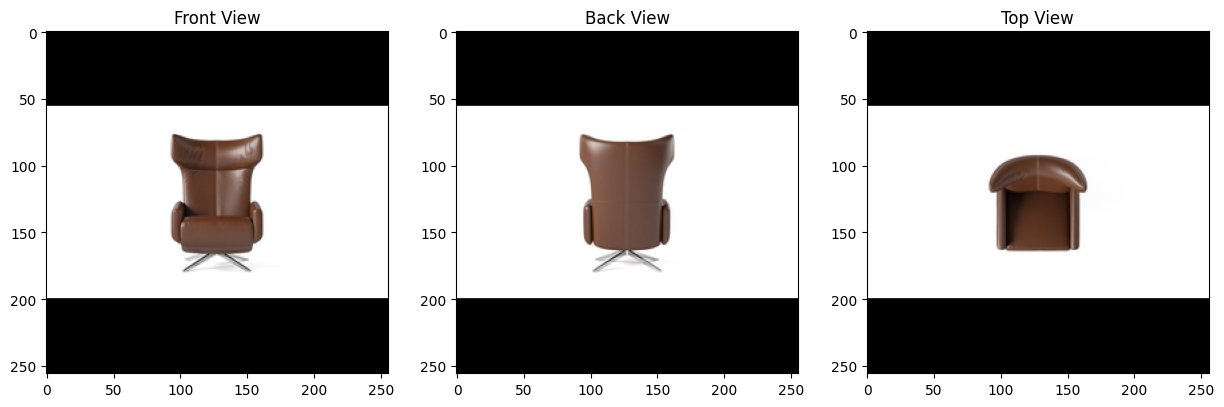

In [12]:

def load_and_normalize_images(path, target_size=(256, 256)):
    """Load image and resize while maintaining aspect ratio"""
    # Open image with PIL
    img = Image.open(path)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    
    # Convert to RGB mode
    img = img.convert('RGB')
    
    # Calculate aspect ratio preserving resize dimensions
    w, h = img.size
    aspect = w / h
    
    if aspect > 1:
        new_w = target_size[0]
        new_h = int(target_size[0] / aspect)
    else:
        new_h = target_size[1]
        new_w = int(target_size[1] * aspect)
    
    # Create new image with padding
    resized_img = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    new_img = Image.new('RGB', target_size, (0, 0, 0))
    
    # Paste resized image in center
    paste_x = (target_size[0] - new_w) // 2
    paste_y = (target_size[1] - new_h) // 2
    new_img.paste(resized_img, (paste_x, paste_y))
    
    return new_img

# Load and resize images
front_img = load_and_normalize_images(front_path)
back_img = load_and_normalize_images(back_path)
top_img = load_and_normalize_images(top_path)

# Plot original images
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(front_img)
plt.title('Front View')
plt.subplot(132)
plt.imshow(back_img)
plt.title('Back View')
plt.subplot(133)
plt.imshow(top_img)
plt.title('Top View')
plt.show()


In [36]:
def create_object_mesh(image_input, depth_threshold=0.75):
    print("Image type:", image_input.__class__)
    
    # Step 1: Convert input to numpy array with proper format
    if isinstance(image_input, str):
        # Loading from file path
        image = cv2.imread(image_input)
        if image is None:
            raise ValueError(f"Failed to load image from path: {image_input}")
    elif isinstance(image_input, Image.Image):
        # Convert PIL Image to numpy array
        # First convert to RGB numpy array
        image_array = np.array(image_input)
        # Then convert from RGB to BGR for OpenCV
        image = cv2.cvtColor(image_array, cv2.COLOR_RGB2BGR)
    else:
        # Assume it's already a numpy array
        image = image_input
    
    # Step 2: Verify array format
    if not isinstance(image, np.ndarray):
        raise TypeError("Image must be converted to numpy array")
    if len(image.shape) != 3:
        raise ValueError("Image must be a 3-channel color image")
    
    # Step 3: Convert to grayscale
    try:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    except cv2.error as e:
        print("Error during color conversion. Image shape:", image.shape)
        print("Image dtype:", image.dtype)
        raise ValueError("Failed to convert image to grayscale") from e
    
    # Step 4: Visualize grayscale image
    plt.figure(figsize=(15, 5))
    plt.imshow(image_gray, cmap='gray')  # Specify colormap for grayscale
    plt.title('Grayscale Image')
    plt.show()
    
    # Step 5: Edge detection
    try:
        edges = cv2.Canny(image_gray, 100, 200)
        kernel = np.ones((5, 5), np.uint8)
        dilated_edges = cv2.dilate(edges, kernel, iterations=1)
    except cv2.error as e:
        print("Error during edge detection. Grayscale image shape:", image_gray.shape)
        print("Grayscale image dtype:", image_gray.dtype)
        raise ValueError("Failed during edge detection") from e
    
    contours, _ = cv2.findContours(dilated_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        return None
        
    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros(image_gray.shape, dtype=np.uint8)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    mask_blurred = cv2.GaussianBlur(mask, (1, 1), 0)
    
    output_image = np.zeros_like(image)
    output_image[mask_blurred > 0] = image[mask_blurred > 0]
    
    # Get depth map using Depth Anything model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    depth_model = pipeline("depth-estimation", model="depth-anything/Depth-Anything-V2-base-hf", device=device)
    
    # Convert to PIL Image for depth estimation
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)
    depth_predictions = depth_model(image_pil)
    depth_map = np.array(depth_predictions["depth"])

    # Add this section
    
    # depth_map = integrate_foreground_processing(image, depth_map)
    
    # Process depth map
    height, width, _ = output_image.shape
    depth_map_resized = cv2.resize(depth_map, (width, height))
    
    # Apply mask to depth map
    mask_resized = cv2.resize(mask, (depth_map_resized.shape[1], depth_map_resized.shape[0]))
    mask_contour = mask_resized > 0
    depth_edges = np.zeros_like(depth_map_resized)
    depth_edges[mask_contour] = depth_map_resized[mask_contour]
    depth_edges_smoothed = cv2.GaussianBlur(depth_edges, (5, 5), 0)
    
    # Normalize depth values
    depth_norm = (depth_edges_smoothed - depth_edges_smoothed.min()) / (depth_edges_smoothed.max() - depth_edges_smoothed.min())
    
    # Convert to RGB for visualization
    output_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)
    
    # Create coordinate grids
    x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
    
    # Flatten arrays
    x_coords_flat = x_coords.ravel().tolist()
    y_coords_flat = y_coords.ravel().tolist()
    z_coords_flat = depth_norm.ravel().tolist()
    colors_flat = output_rgb.reshape(-1, 3).tolist()
    
    # Apply depth threshold and create mask for valid points
    mask = []
    for z, color in zip(z_coords_flat, colors_flat):
        is_valid = (z > depth_threshold) and not (color[0] == 0 and color[1] == 0 and color[2] == 0)
        mask.append(is_valid)
    
    # Filter points based on mask
    x_filtered = [x for x, m in zip(x_coords_flat, mask) if m]
    y_filtered = [y for y, m in zip(y_coords_flat, mask) if m]
    z_filtered = [z for z, m in zip(z_coords_flat, mask) if m]
    colors_filtered = [c for c, m in zip(colors_flat, mask) if m]
    
    # Create the Plotly figure
    fig = go.Figure(data=[go.Scatter3d(
        x=x_filtered,
        y=y_filtered,
        z=z_filtered,
        mode='markers',
        marker=dict(
            size=2,
            color=[f'rgb({r}, {g}, {b})' for r, g, b in colors_filtered],
            opacity=1
        )
    )])
    
    # Update layout
    fig.update_layout(
        scene=dict(
            xaxis=dict(nticks=10, range=[0, width]),
            yaxis=dict(nticks=10, range=[0, height]),
            zaxis=dict(nticks=10, range=[0, max(z_filtered)]),
        ),
        margin=dict(l=0, r=0, b=0, t=30)
    )
    
    return fig


def combine_front_back_meshes(front_fig, back_fig, depth_threshold=0.25, sampling_rate=0.5):
    """
    Creates an optimized 3D visualization combining front and back mesh views.
    
    Args:
        front_fig: Plotly figure of front mesh
        back_fig: Plotly figure of back mesh
        depth_threshold: Depth threshold value
        sampling_rate: Fraction of points to keep (0.0 to 1.0)
    """
    def extract_points(fig):
        if fig is None or not fig.data:
            return [], [], [], []
        trace = fig.data[0]
        return (
            np.array(trace.x), 
            np.array(trace.y), 
            np.array(trace.z), 
            [c.strip('rgb()').split(',') for c in trace.marker.color]
        )
    
    def sample_points(x, y, z, colors, rate):
        """Efficiently sample points using numpy"""
        n_points = len(x)
        n_sample = int(n_points * rate)
        if n_sample >= n_points:
            return x, y, z, colors
        
        # Use numpy's random choice for efficient sampling
        indices = np.random.choice(n_points, n_sample, replace=False)
        indices.sort()  # Sort for better memory access patterns
        
        return (x[indices], y[indices], z[indices],
                [colors[i] for i in indices])
    
    # Extract points and convert to numpy arrays for faster processing
    front_x, front_y, front_z, front_colors = extract_points(front_fig)
    back_x, back_y, back_z, back_colors = extract_points(back_fig)
    
    # Sample points if needed
    front_x, front_y, front_z, front_colors = sample_points(
        front_x, front_y, front_z, front_colors, sampling_rate)
    back_x, back_y, back_z, back_colors = sample_points(
        back_x, back_y, back_z, back_colors, sampling_rate)
    
    # Calculate dimensions using numpy operations
    original_width = max(np.max(front_x), np.max(back_x))
    original_height = max(np.max(front_y), np.max(back_y))
    aspect_ratio = original_width / original_height
    
    # Center views using vectorized operations
    front_width = np.max(front_x) - np.min(front_x)
    back_width = np.max(back_x) - np.min(back_x)
    
    front_x_centered = front_x - np.min(front_x) - front_width/2
    back_x_centered = -(back_x - np.min(back_x) - back_width/2)
    
    # Normalize z-coordinates using vectorized operations
    front_z_norm = 0.5 + (front_z - np.min(front_z)) * depth_threshold / (np.max(front_z) - np.min(front_z))
    back_z_norm = 0.5 - (back_z - np.min(back_z)) * depth_threshold / (np.max(back_z) - np.min(back_z))
    
    # Convert colors to RGB strings efficiently
    def process_colors(colors):
        return [f'rgb({",".join(c)})' for c in colors]
    
    front_colors_processed = process_colors(front_colors)
    back_colors_processed = process_colors(back_colors)
    
    # Combine points using numpy concatenation
    combined_x = np.concatenate([front_x_centered, back_x_centered])
    combined_y = np.concatenate([front_y, back_y])
    combined_z = np.concatenate([front_z_norm, back_z_norm])
    combined_colors = front_colors_processed + back_colors_processed
    
    # Create the figure
    combined_fig = go.Figure(data=[go.Scatter3d(
        x=combined_x,
        y=combined_y,
        z=combined_z,
        mode='markers',
        marker=dict(
            size=2,
            color=combined_colors,
            opacity=1
        ),
        showlegend=False
    )])
    
    # Update layout with minimal settings
    combined_fig.update_layout(
        scene=dict(
            aspectratio=dict(x=1, y=1/aspect_ratio, z=0.5),
            aspectmode='manual',
            camera=dict(
                eye=dict(x=1.25, y=-0.25, z=1.25),
                up=dict(x=0, y=0, z=0),
                center=dict(x=0, y=0, z=0)
            ),
            xaxis=dict(
                range=[-original_width/2, original_width/2],
                showticklabels=False, showgrid=False,
                zeroline=False, showline=False, showbackground=False
            ),
            yaxis=dict(
                range=[0, original_height],
                showticklabels=False, showgrid=False,
                zeroline=False, showline=False, showbackground=False
            ),
            zaxis=dict(
                range=[0, 1],
                showticklabels=False, showgrid=False,
                zeroline=False, showline=False, showbackground=False
            )
        ),
        uirevision='true',
        showlegend=False,
        margin=dict(l=0, r=0, t=0, b=0, pad=0),
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)'
    )
    
    return combined_fig



def process_orthogonal_views(front, back=None, top=None, depth_threshold=0.25, sampling_rate=1.0):
    # Process all three views
    image_paths = {
        'front': f"{front}",
        'back': f"{back}",
        'top': f"{top}"
    }

    # First normalize all images
    try:
        
        # Load and resize images
        front_img = load_and_normalize_images(front_path)
        back_img = load_and_normalize_images(back_path)
        top_img = load_and_normalize_images(top_path)

        # Plot original images
        plt.figure(figsize=(15, 5))
        plt.subplot(131)
        plt.imshow(front_img)
        plt.title('Front View')
        plt.subplot(132)
        plt.imshow(back_img)
        plt.title('Back View')
        plt.subplot(133)
        plt.imshow(top_img)
        plt.title('Top View')
        plt.show()
        print("\nAll images successfully normalized to size:")

        # First, let's get our three normalized meshes individually
        front_fig = create_object_mesh(front_img, depth_threshold=depth_threshold)
        back_fig = create_object_mesh(back_img, depth_threshold=depth_threshold)
        top_fig = create_object_mesh(top_img, depth_threshold=depth_threshold)

         # For maximum quality (but slower)
        combined_mesh = combine_front_back_meshes(front_fig, back_fig, sampling_rate=sampling_rate)
        return combined_mesh.to_dict()
    
    except Exception as e:
        print(f"Error during image normalization: {str(e)}")
        return None

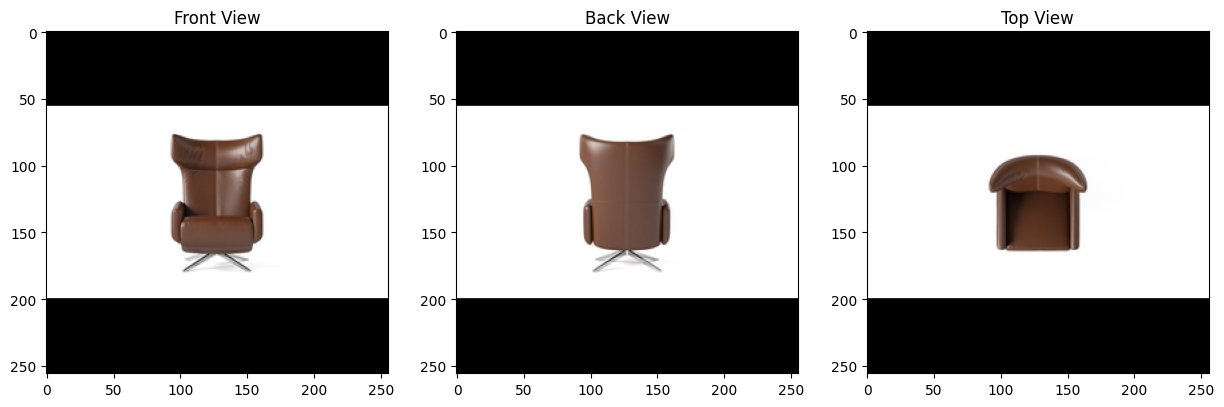


All images successfully normalized to size:
Image type: <class 'PIL.Image.Image'>


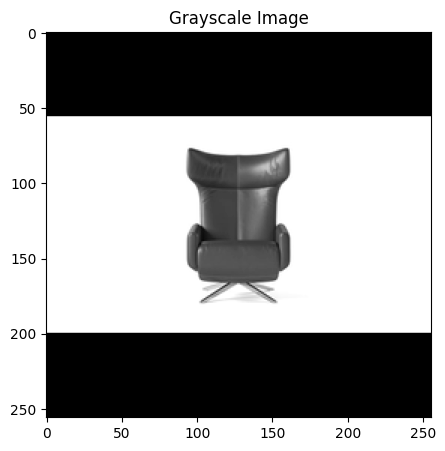

Image type: <class 'PIL.Image.Image'>


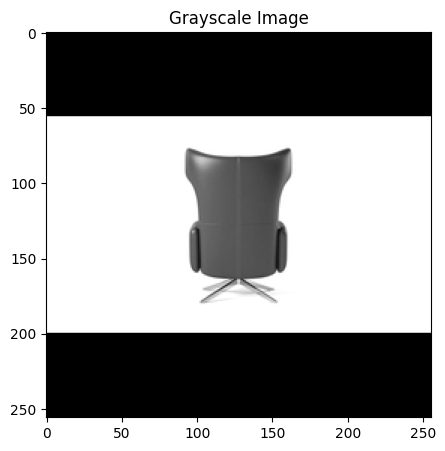

Image type: <class 'PIL.Image.Image'>


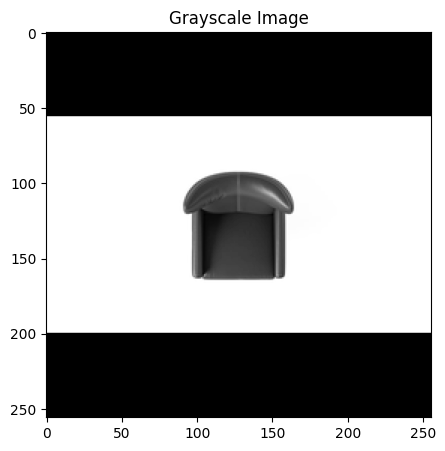

In [37]:
# Define folder path and load images
folder = "../static/uploads/Chair/"
front_path = f"{folder}/front.jpg"
back_path = f"{folder}/back.jpg"
top_path = f"{folder}/top.jpg"


figure = process_orthogonal_views(front_path, back_path, top_path)